**Text Analysis Capstone Project: An Exploration of Environmental Reproductive Health Language in Pronatalist Policy Document 'Mandate For Leadership Project 2025'**

**Author:** Kelly Hogan

**Date:** 2025-2026

**Environmental Research Question:** 
My project is inspired by the distinctly pronatalist policy position of the current administration, which encourages women to prioritize expanion of their familes. The Heritage Foundation’s ‘Mandate for Leadership Project 2025’ is a policy mired in anti-immigration sentiment, replacement theory, and far-right nationalism, which re-envisions a society shaped by ultra-conservative values. What this pronatalist mandate likely neglects, however, is evidence that planned environmental deregulation will impact the health of pregnant women and their offspring. I use the Heritage Foundation’s text as data to demonstrate the inconsistency of pronatalism and anti-environmentalism.

My Capstone Project will explore the tension between pronatalism and existing evidence suggesting that environmental exposures and climate change contributes to poorer preganancy and birth outcomes. I perform analyses of text that relates to women’s health, the environment, and the intersection of these categories. Using a natural language processing (NLP) pipeline adapted from code along notebooks, I perform preprocessing (e.g.,cleaning, tokenizing), sentiment analysis using a Bing dictionary, regression analysis (e.g., Lasso), and train a language model to predict themes (e.g., TF-IDF/glmnet pipeline).

My goal is that the output of this project sheds light on the presence or absence of text at the intersection of environmental protection and healthy pregnancy outcomes and the inconsistency of environmental deregulation and pronatalism. Through analysis of a critical policy document driving federal decision-making, executive orders, and deregulation, I provide some insight into the uncoupling of policy related to environmental protection and healthy pregnancy outcomes.


**Link to GitHub repository:** https://github.com/Toxikell/Deciduous_Beginnings

**Loading R Packages**

**References**
Course 1, Module 2, Lesson 1 and 2: "Base R" by Aie Creel — Provides an introduction to coding in R programming language, covering comments, basic datatypes, methods for storing data, and data frames


In [47]:
# Load the required packages
library(tidyverse)     # Data manipulation and visualization
library(tidytext)      # Text mining with tidy data principles
library(wordcloud2)    # Word cloud visualization
library(tm)            # Text mining utilities
library(SnowballC)     # Stemming
library(ggplot2)       # Data visualization
library(dplyr)         # Data manipulation
library(stringr)       # String manipulation
library(knitr)         # For nice table output
library(scales)        # For better plot scales
library(topicmodels)   # Topic modeling (LDA)
library(RColorBrewer)  # Color palettes
library(broom)         # Tidy model outputs
library(tidyr)         # Tidy up data
library(janitor)       # Generating tables
library(caret)         # Machine learning framework
library(e1071)         # Naive Bayes classifier
library(randomForest)  # Random Forest (bonus)
library(glmnet)        # Regularized regression
library(Matrix)        # Sparse matrices
library(stringi)       # Unicode corrector
library(moments)       # Distribution shape
library(purrr)         # Additional TF-IDF pipeline functions
library(tibble)        # Data frame fixer
library(pheatmap)      # Heat maps
library(viridis)       # Color palettes


**Loading Data**
Course 1, Module 1: Data sources (Eli Fenichel)
Course 2, Module 5: Preprocessing datasets (Eli Fenichel)

**Method**
The Heritage Foundation's Project2025 policy document 'Mandate for Leadership' was downloaded from https://static.heritage.org/project2025/2025_MandateForLeadership_FULL.pdf and converted to a text file so that front matter, section author names, author's acknowledgements, and references could be removed manually. I assigned a document identifier to each line of text instead of to the entire corpus because I wanted to compute TF-IDF and anticipated that this type of analysis would be less meaningful on a single document. My rationale was that assigning muliple document identifiers to the text would allow me to analyze the entirety of the policy paper by breaking the corpus into pieces. An alternative approach (or future direction, perhaps) might be to compare 'Mandate for Leadership' with another relevant pronatalist Project 2025 policy document such as 'Save America by Saving the Family'.

**References**
Course 1, Module 2, Lesson 1 and 2: "Base R" by Aie Creel — Provides an introduction to coding in R programming language, covering comments, basic datatypes, methods for storing data, and data frames

In [5]:
#Load Mandate For Leadership text data
MFL_text <- readLines("2025_MandateForLeadership.txt")

# Examine the structure of our data
str(MFL_text)

# Look at the first few rows
head(MFL_text, 3)



 chr [1:9783] "" ...


[1] ""                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
[2] "Forty-four years ago, the United States and the conservative movement were in dire straits. Both had been betrayed by the Washington establishment and were uncertain whom to trust. Both were internally splintered and stra\xadtegically adrift. Worse still, at that moment of acute vulnerability and division, we found ourselves besieged by existential adversaries, foreign and domestic. The late 1970s were by any measure a historic low point for America and the political coa\xadlition dedicated to preserving its unique legacy of human flourishing and freedom."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
[3] "Today, America and the conservative movement are enduring an era of division and danger akin to the late 1970s. Now, as then, our political class has been discred\xadited by wholesale dishonesty and corruption. Look at America under the ruling and cultural elite today: Inflation is ravaging family budgets, drug overdose deaths continue to escalate, and children suffer the toxic normalization of transgender\xadism with drag queens and pornography invading their school libraries. Overseas, a totalitarian Communist dictatorship in Beijing is engaged in a strategic, cultural, and economic Cold War against America\x92s interests, values, and people\x97all while globalist elites in Washington awaken only slowly to that growing threat. Moreover, low-income communities are drowning in addiction and government dependence. Contemporary elites have even repurposed the worst ingredients of 1970s \x93radical chic\x94 to build the totalitarian cult known today as \x93The Great Awokening.\x94 And now, as then, the Republican Party seems to have little understanding about what to do. Most alarming of all, the very moral foundations of our society are in peril."

**Create tibble of Unicode-free text**

**Method**
Creating a tibble containing document_id and text columns from my text file produced an error message that gave a warning about the presence of Unicode artifact. This error may have resulted from saving the pdf as a txt file and was likely to create issues downstream during tokenization, TF-IDF, or LDA.  Adding a line of script that removes non-word characters permitted this document to load without warning.

**References**
Course 1 , Module 3: "Data Manipulation with Tidyverse" by Andy Creel— Demonstrates how the Tidyverse facilitates data cleaning, transformation, and visualization.

In [6]:
#Build the main tibble

MFL_text_tbl <- tibble(
    document_id = seq_along(MFL_text),
    text = MFL_text
    )

MFL_text_tbl <- MFL_text_tbl %>%
  mutate(text = stri_replace_all_regex(
    text,
    "[^\\p{L}\\p{N}\\p{P}\\p{Z}\\p{M}]",
    " "
  ))

MFL_text_tbl <- MFL_text_tbl %>%
  mutate(text = stri_trans_nfc(text))

glimpse(MFL_text_tbl)

Rows: 9,783
Columns: 2
$ document_id <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17,…
$ text        <chr> "", "Forty-four years ago, the United States and the conse…


**Data cleaning**

**Method** I removed non-words from the corpus based on suggestions from the code along notebook from the text analysis module and changed the column name to clean text.

**References** Course 4, Module 13, Lesson 2: "Text Analysis for Environmental Data" by Luke Sanford — Covers cleaning, tokenization, stop-word removal, word-frequency analysis, sentiment analysis, building custom dictionaries, and visualizations

Course 4, Module 13, Lesson 3: "Converting Text to Quantitative Data" by Luke Sanford —Transform raw text into numerical data using preprocessing, word frequencies, dictionaries, and introduces TF-IDF and topic modeling as tools to uncover distinctive terms and thematic structures

In [7]:
#Clean text 
clean_MFL_text <- MFL_text_tbl %>%
  
  # Convert to lowercase 
  mutate(text = tolower(text))%>%
  # Remove punctuation
  mutate(text = str_replace_all(text, "[[:punct:]]", " "))%>%
  # Remove Twitter handles
  mutate(text = str_replace_all(text, "https?://\\S+", " "))%>%
  # Remove URLs (simple pattern)
  mutate(text = str_replace_all(text, "https?://\\S+", ""))%>%
  # Remove hashtags but keep the words
  mutate(text = str_replace_all(text, "#", ""))%>% 
  #Remove stopwords
  mutate(text = removeWords(text, stopwords("en")))%>%
  #Remove numbers
  mutate(text = str_replace_all(text, "\\b\\d+\\b", " "))%>%
  #Remove very short tokens
  mutate(text = str_replace_all(text, "\\b\\w{1,2}\\b", " "))%>%
  #Remove whitespace 
  mutate(text = str_squish(text))%>%
  filter(text !="")

# Add cleaned text column
clean_MFL_text <- clean_MFL_text %>%
  rename(text_clean = text) %>%
  select(document_id, text_clean)

clean_MFL_text %>% slice_head(n = 6)
         

document_id,text_clean
<int>,<chr>
2,forty four years ago united states conservative movement dire straits betrayed washington establishment uncertain trust internally splintered stra tegically adrift worse still moment acute vulnerability division found besieged existential adversaries foreign domestic late 1970s measure historic low point america political coa lition dedicated preserving unique legacy human flourishing freedom
3,today america conservative movement enduring era division danger akin late 1970s now political class discred ited wholesale dishonesty corruption look america ruling cultural elite today inflation ravaging family budgets drug overdose deaths continue escalate children suffer toxic normalization transgender ism drag queens pornography invading school libraries overseas totalitarian communist dictatorship beijing engaged strategic cultural economic cold war america interests values people globalist elites washington awaken slowly growing threat moreover low income communities drowning addiction government dependence contemporary elites even repurposed worst ingredients 1970s radical chic build totalitarian cult known today great awokening now republican party seems little understanding alarming moral foundations society peril
4,yet students history will note notwithstanding challenges late 1970s proved moment political right unified country led united states historic political economic global victories
5,heritage foundation proud played small pivotal role story early amid stagflation gas lines red army inva sion afghanistan nadir jimmy carter days malaise heritage launched mandate leadership project brought together hundreds conservative scholars academics across conservative movement together team created volume page governing handbook containing conservative policies reform federal government rescue american people washington dysfunction promise conservative movement country confident specific clear
6,mandate leadership published january month ronald reagan sworn presidency end year percent recommendations become policy reagan way ending stagflation reviving american confidence prosperity winning cold war
7,bad news today political establishment cultural elite driven america toward decline good news know way even though challenges today 1970s conservatives confident can rescue kids reclaim culture revive economy defeat anti american left home abroad will


**Data joining**

**Method** I used the left_join dpylr function to join the text tibble with cleaned text.

**References** Course 2, Module 5: "Data Manipulation with Tidyverse" by Andie Creel — Dataset integration and reshaping using the tidyr package and dplyr functions

In [8]:
#Merging cleaned text back into the main tibble
MFL_text_with_labels <- MFL_text_tbl %>%
  left_join(clean_MFL_text, by = "document_id")

# Inspect
MFL_text_with_labels %>% slice_head(n = 6)

document_id,text,text_clean
<int>,<chr>,<chr>
1,,NA
2,"Forty-four years ago, the United States and the conservative movement were in dire straits. Both had been betrayed by the Washington establishment and were uncertain whom to trust. Both were internally splintered and stra tegically adrift. Worse still, at that moment of acute vulnerability and division, we found ourselves besieged by existential adversaries, foreign and domestic. The late 1970s were by any measure a historic low point for America and the political coa lition dedicated to preserving its unique legacy of human flourishing and freedom.",forty four years ago united states conservative movement dire straits betrayed washington establishment uncertain trust internally splintered stra tegically adrift worse still moment acute vulnerability division found besieged existential adversaries foreign domestic late 1970s measure historic low point america political coa lition dedicated preserving unique legacy human flourishing freedom
3,"Today, America and the conservative movement are enduring an era of division and danger akin to the late 1970s. Now, as then, our political class has been discred ited by wholesale dishonesty and corruption. Look at America under the ruling and cultural elite today: Inflation is ravaging family budgets, drug overdose deaths continue to escalate, and children suffer the toxic normalization of transgender ism with drag queens and pornography invading their school libraries. Overseas, a totalitarian Communist dictatorship in Beijing is engaged in a strategic, cultural, and economic Cold War against America s interests, values, and people all while globalist elites in Washington awaken only slowly to that growing threat. Moreover, low-income communities are drowning in addiction and government dependence. Contemporary elites have even repurposed the worst ingredients of 1970s radical chic to build the totalitarian cult known today as The Great Awokening. And now, as then, the Republican Party seems to have little understanding about what to do. Most alarming of all, the very moral foundations of our society are in peril.",today america conservative movement enduring era division danger akin late 1970s now political class discred ited wholesale dishonesty corruption look america ruling cultural elite today inflation ravaging family budgets drug overdose deaths continue escalate children suffer toxic normalization transgender ism drag queens pornography invading school libraries overseas totalitarian communist dictatorship beijing engaged strategic cultural economic cold war america interests values people globalist elites washington awaken slowly growing threat moreover low income communities drowning addiction government dependence contemporary elites even repurposed worst ingredients 1970s radical chic build totalitarian cult known today great awokening now republican party seems little understanding alarming moral foundations society peril
4,"Yet students of history will note that, notwithstanding all those challenges, the late 1970s proved to be the moment when the political Right unified itself and the country and led the United States to historic political, economic, and global victories.",yet students history will note notwithstanding challenges late 1970s proved moment political right unified country led united states historic political economic global victories
5,"The Heritage Foundation is proud to have played a small but pivotal role in that story. It was in early 1979 amid stagflation, gas lines, and the Red Army s inva sion of Afghanistan, the nadir of Jimmy Carter s days of malaise that Heritage launched the Mandate for Leadership project. We brought together hundreds of conservative scholars and academics across the conservative movement. Together, this team created a 20-volume, 3,000-page governing handbook containing more than 2,000 conservative policies to reform the federal government and rescue the American people from W

**Text annotating/Document classification**

**Method** I identified keywords related to women's health (WH) and the environment (ENV); detected the presence of these terms in the text using str_detect() function from the stringr package; assigned labels (WH and ENV and the INTERSECTION of WH and ENV); and summarized label distribution in a table.

**References**
Course 4, Module 13, Lesson 2: "Text Analysis for Environmental Data" by Luke Sanford — Covers cleaning, tokenization, stop-word removal, word-frequency analysis, sentiment analysis, building custom dictionaries, and visualizations


In [9]:
#Add labels

wh_keywords <- c(
  "women", "woman", "maternal", "reproductive", "pregnancy",
  "contraception", "family planning", "abortion", "prenatal",
  "postpartum", "women's health", "gender health", "maternal mortality"
)

env_keywords <- c(
  "environment", "environmental", "epa", "pollution", "climate",
  "warming", "carbon", "emissions", "clean air", "clean water",
  "toxics", "hazardous", "superfund", "ecosystem", "biodiversity",
  "renewable", "solar", "wind", "fossil fuel", "energy regulation",
  "water quality", "air quality", "chemical exposure"
)

MFL_text_with_labels <- MFL_text_with_labels %>%
    mutate(
    ENV = str_detect(
      text_clean,
      regex(paste(env_keywords, collapse = "|"), ignore_case = TRUE)
    ),
    WH = str_detect(
      text_clean,
      regex(paste(wh_keywords, collapse = "|"), ignore_case = TRUE)
    ),
    INTERSECTION = ifelse(ENV & WH, 1, 0) 
  )


env_tab <- table(MFL_text_with_labels$ENV)
names(env_tab) <- c("Not Environmental", "Environmental")
attr(env_tab, "label") <- "Environmental Label Distribution"
env_tab

wh_tab <- table(MFL_text_with_labels$WH)
names(wh_tab) <- c("Not Women's Health", "Women's Health")
attr(wh_tab, "label") <- "Women's Health Label Distribution"
wh_tab

intersection_tab <- table(MFL_text_with_labels$INTERSECTION)
names(intersection_tab) <- c("No Overlap", "ENV & WH Overlap")
attr(intersection_tab, "label") <- "Intersection of Environmental and Women's Health Content"
intersection_tab


MFL_text_with_labels %>%
  count(ENV, WH, INTERSECTION)



Not Environmental     Environmental 
             4161              1085 

Not Women's Health     Women's Health 
              5098                148 

      No Overlap ENV & WH Overlap 
            5218               28 

ENV,WH,INTERSECTION,n
<lgl>,<lgl>,<dbl>,<int>
FALSE,FALSE,0,4041
FALSE,TRUE,0,120
TRUE,FALSE,0,1057
TRUE,TRUE,1,28
NA,NA,NA,4537


**Data labeling/Label validation**

**Method** I identified the documents (lines of text) that contain terms at the intersection of ENV and WH (called INTERSECTION). This is a way to validate whether or not my label choices are adequately comprehensive.  Based on the first six data points, the output suggests that keywords might be finessed to more robustly capture intersections. This script serves as an internal control to assure adequacy of labels.

In [10]:
#Create a label intersection category
intersection_docs <- MFL_text_with_labels %>%
  filter(INTERSECTION == 1)

intersection_docs%>% slice_head(n = 6)

document_id,text,text_clean,ENV,WH,INTERSECTION
<int>,<chr>,<chr>,<lgl>,<lgl>,<dbl>
81,Bureaucrats at the State Department infuse U.S. foreign aid programs with woke extremism about intersectionality and abortion.3,bureaucrats state department infuse foreign aid programs woke extremism intersectionality abortion,TRUE,TRUE,1
435,"The NSC should take a leading role in directing the drafting and thorough review of all formal strategies: the National Security Strategy, the National Defense Strat egy, the Nuclear Posture Review, the Missile Defense Strategy, etc. In particular, the National Defense Strategy, which by tradition has evaded significant review, should be prioritized for White House review by the NSC and OMB. Both should also conduct reviews of operational war plans and global force planning and allo cations with the Secretary of Defense to align them with presidential priorities and review all key policy and guidance intended for implementation by the heads of the Department of Defense, the Department of State, and the Intelligence Community before they are authorized for distribution. The NSC should rigorously review all general and flag officer promotions to prioritize the core roles and responsibilities of the military over social engineering and non-defense matters, including climate change, critical race theory, manufactured extremism, and other polarizing policies that weaken our armed forces and discourage our nation s finest men and women from enlisting to serve in defense of our liberty.",nsc take leading role directing drafting thorough review formal strategies national security strategy national defense strat egy nuclear posture review missile defense strategy etc particular national defense strategy tradition evaded significant review prioritized white house review nsc omb also conduct reviews operational war plans global force planning allo cations secretary defense align presidential priorities review key policy guidance intended implementation heads department defense department state intelligence community authorized distribution nsc rigorously review general flag officer promotions prioritize core roles responsibilities military social engineering non defense matters including climate change critical race theory manufactured extremism polarizing policies weaken armed forces discourage nation finest men women enlisting serve defense liberty,TRUE,TRUE,1
615,"The good news is that most enlisted personnel, and most officers, especially below the rank of general or admiral, continue to be patriotic defenders of liberty. But this is now Barack Obama s general officer corps. That is why Russ Vought argues in Chapter 2 that the National Security Council should rigorously review all general and flag officer promotions to prioritize the core roles and responsi bilities of the military over social engineering and non-defense related matters, including climate change, critical race theory, manufactured extremism, and other polarizing policies that weaken our armed forces and discourage our nation s finest men and women from enlisting. Ensuring that many of America s best and bright est continue to choose military service is essential.",good news enlisted personnel officers especially rank general admiral continue patriotic defenders liberty now barack obama general officer corps russ vought argues chapter national security council rigorously review general flag officer promotions prioritize core roles responsi bilities military social engineering non defense related matters including climate change critical race theory manufactured extremism polarizing policies weaken armed forces discourage nation finest men women enlisting ensuring many america best bright est continue choose military service essential,TRUE,TRUE,1
624,"Former chief of staff for the director of National Intelligence Dustin Carmack writes in Chapter 7 that the U.S. Intelligence Community is too inclined to look in the rearview mirror, engage in gr

**Data visualization**

**Method** I plotted distribution of labels, including columns dedicated to documents that contained no labels.  Labels in this dataset are infrequent with terms related to women's health occuring 86% less frequently than terms related to the environment.  The intersection of these terms is nearly non-existent.

**References** Course 1, Module 4: "Basic Data Visualization" by Andie Creel — Introduces plotting in R using box plots, bar charts, scatter plots, and multiple plot layouts

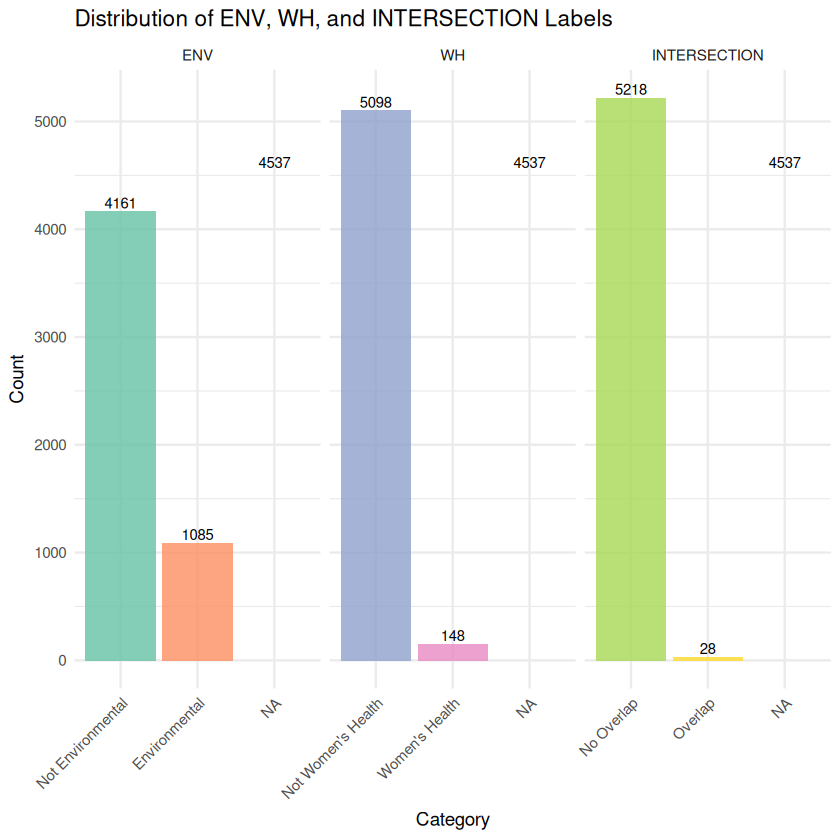

In [11]:
#Plot distibution of labels

plot_data <- MFL_text_with_labels %>%
  select(ENV, WH, INTERSECTION) %>%
  mutate(
    ENV = ifelse(ENV, "Environmental", "Not Environmental"),
    WH = ifelse(WH, "Women's Health", "Not Women's Health"),
    INTERSECTION = ifelse(INTERSECTION == 1, "Overlap", "No Overlap")
  ) %>%
  pivot_longer(
    cols = c(ENV, WH, INTERSECTION),
    names_to = "LabelType",
    values_to = "LabelValue"
  ) %>%

    mutate(
    LabelValue=factor(
    LabelValue,
    levels=c(
        "Not Environmental", "Environmental",
        "Not Women's Health", "Women's Health",
        "No Overlap", "Overlap"
    )  ),

  LabelType = factor(
      LabelType, 
      levels = c("ENV", "WH", "INTERSECTION"))
  )
        
plot_data %>%
  ggplot(aes(x = LabelValue, fill = LabelValue)) +
  geom_bar(alpha = 0.8) +
geom_text(
  stat = "count",
  aes(label = after_stat(count)),
  vjust = -0.3,
  size = 3
) +  

facet_wrap(~ LabelType, scales = "free_x") +
  labs(
    title = "Distribution of ENV, WH, and INTERSECTION Labels",
    x = "Category",
    y = "Count"
  ) +
  theme_minimal() +
  scale_fill_brewer(type = "qual", palette = "Set2") +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none"
  )        
 

**Tokenization**

**Method** I used a TF-IDF preprocessing pipeline (e.g., tokens, stems filter, rare word filter, counts compute TF-IDF) to prepare text for TD-IDF analyses (e.g., frequency, inverse frequency, weighting).

**References**
Course 4, Module 13, Lesson 2: "Text Analysis for Environmental Data" by Luke Sanford — Covers cleaning, tokenization, stop-word removal, word-frequency analysis, sentiment analysis, building custom dictionaries, and visualizations


In [12]:
#Tokenize dataset for TF-IDF
MFL_text_tokens <- MFL_text_with_labels %>% 
    unnest_tokens(word, text) %>% 
    anti_join(stop_words, by = "word") %>% 
    filter(nchar(word) > 1) %>% 
    filter(!str_detect(word, "^\\d+")) %>% 
    filter(str_detect(word, "^[a-z]+$"))%>%
    filter(!str_detect(word, "http"))%>%
    mutate(word_stem = SnowballC::wordStem(word))%>%

#Count words 
count(document_id, word, word_stem) %>%
    group_by(word) %>% 
    filter(n() > 1) %>%
    ungroup()%>%
    bind_tf_idf(word, document_id, n) #Note-did not group before tf-idf; also ungrouped to be safe

head(MFL_text_tokens, 5)


document_id,word,word_stem,n,tf,idf,tf_idf
<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
2,acute,acut,1,0.02631579,6.955593,0.18304191
2,adrift,adrift,1,0.02631579,7.871883,0.20715482
2,adversaries,adversari,1,0.02631579,4.521979,0.11899945
2,ago,ago,1,0.02631579,5.473988,0.14405232
2,america,america,1,0.02631579,2.977782,0.07836268


In [13]:
# Get basic statistics about tokenized data
cat("Total number of tokens:", nrow(MFL_text_tokens), "\n")           
cat("Number of unique words:", length(unique(MFL_text_tokens$word)), "\n")
cat("Average words per document:", round(nrow(MFL_text_tokens) / length(unique(MFL_text_tokens$document_id)), 1), "\n")

Total number of tokens: 121097 


Number of unique words: 8689 


Average words per document: 23.1 


**Data joining**

**Method** I used the left_join dpylr function to join the TF-IDF tokens with document labels. 

**References** Course 2, Module 5: "Data Manipulation with Tidyverse" by Andie Creel — Dataset integration and reshaping using the tidyr package and dplyr functions

In [14]:
#Join TF-IDF tokens and document labels and group by document
MFL_text_tokens %>%
  left_join(
    MFL_text_with_labels %>% 
      select(document_id, ENV, WH, INTERSECTION),
    by = "document_id"
  ) %>%
  group_by(document_id) %>%
  summarise(
    weight = max(tf_idf),
    INTERSECTION = any(INTERSECTION == 1),
    ENV = any(ENV == 1),
    WH = any(WH == 1),
    .groups = "drop"
  ) %>%
  mutate(category = case_when(
    INTERSECTION ~ "Intersection",
    ENV ~ "Environmental",
    WH ~ "Women's Health",
    TRUE ~ "Neutral"
  )) %>%
  arrange(desc(weight))%>%
  slice_head(n = 5) 
  

document_id,weight,INTERSECTION,ENV,WH,category
<int>,<dbl>,<lgl>,<lgl>,<lgl>,<chr>
8463,7.871883,FALSE,FALSE,FALSE,Neutral
8957,7.178736,FALSE,FALSE,FALSE,Neutral
7272,6.955593,FALSE,FALSE,FALSE,Neutral
9741,6.955593,FALSE,FALSE,FALSE,Neutral
2684,6.773271,FALSE,FALSE,FALSE,Neutral


**Data visualization**

**Method** I created a tibble showing token count and frequency categorized by label (ENV, WH, INTERSECTION).  In contrast to the most frequent words, which are 0.45-0.62% of the tokenized corpus, words related to women's health and the environment represent percentages an order of magnitude lower.

**References**
Course 1 , Module 3: "Data Manipulation with Tidyverse" by Andy Creel— Demonstrates how the Tidyverse facilitates data cleaning, transformation, and visualization.

In [15]:
# Display the top 50 most frequent words
MFL_word_freq<-MFL_text_tokens %>%
  count(word, sort = TRUE) %>%
  mutate(percentage = n / sum(n) * 100)

head(MFL_word_freq, 5)

word,n,percentage
<chr>,<int>,<dbl>
administration,839,0.6928330
federal,720,0.5945647
policy,560,0.4624392
government,558,0.4607876
president,549,0.4533556


In [16]:
MFL_word_freq %>%
  filter(word %in% c("women", "women's health", "maternal mortality", "environment", "pregnancy", "pollution", "climate change"))


word,n,percentage
<chr>,<int>,<dbl>
women,55,0.04541814
environment,50,0.04128921
pregnancy,17,0.01403833
pollution,14,0.01156098


**Data visualization**

**Method** I created a word cloud and a bar plot from the 50 most frequent tokens. Among the most frequent tokens are 'federal', 'government', 'president', 'administration'. Less frequent appearing top 50 tokens include 'health' and 'people'. Tokens related to 'environment' and 'women's health' are not among frequent tokens, nor are they among the top 100 tokens.

**References** Course 1, Module 4: "Basic Data Visualization" by Andie Creel — Introduces plotting in R using box plots, bar charts, scatter plots, and multiple plot layouts

In [17]:
# Prepare data for word cloud (top 50 words)

MFL_wordcloud_data <- MFL_word_freq %>%
  head(50) %>% 
  select(word, n)

# Create word cloud
wordcloud2(MFL_wordcloud_data, 
          size = 0.8, 
          color = "random-dark", 
          backgroundColor = "white")

HTML widgets cannot be represented in plain text (need html)

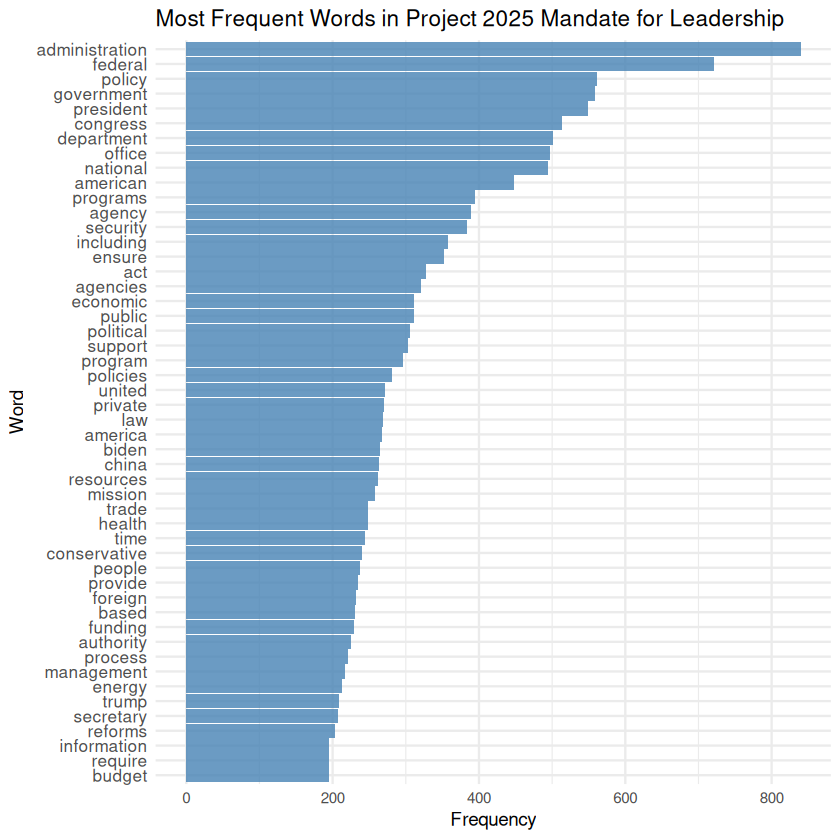

In [18]:
# Create a bar plot of the top 50 most frequent words
MFL_word_freq %>%
  head(50) %>%
  ggplot(aes(x = reorder(word, n), y = n)) +
  geom_col(fill = "steelblue", alpha = 0.8) +
  coord_flip() +
  labs(title = "Most Frequent Words in Project 2025 Mandate for Leadership",
       x = "Word",
       y = "Frequency") +
  theme_minimal() +
  theme(axis.text.y = element_text(size = 10))

**Data visualization**

**Method** I created a word cloud from the top 500 most frequent tokens in each category (ENV, WH, INTERSECTION) to give a qualitative overview of category representation.

In [19]:
wordcloud_TF_IDF <- MFL_text_tokens %>%
    left_join(
    MFL_text_with_labels %>% select(
        document_id, 
        ENV, 
        WH, 
        INTERSECTION),
    by = "document_id") %>%
    group_by(word) %>%
    summarise(
        weight = max(tf_idf),
        ENV = any(ENV),
        WH = any(WH),
        INTERSECTION = any(INTERSECTION == 1), #Note Intersection label was numeric (0/1) rather than logical (T/F)
    .groups = "drop") %>%
    arrange(desc(weight)) %>%
    slice_head(n = 500)

wordcloud_TF_IDF <- wordcloud_TF_IDF %>%
    mutate(color = case_when(
        INTERSECTION == 1 ~ "gold",
        ENV == TRUE       ~ "forestgreen",
        WH == TRUE        ~ "purple",
        TRUE              ~ "gray50"
  ))

wordcloud2(
    data = wordcloud_TF_IDF,
    size = 0.3,
    color = wordcloud_TF_IDF$color,
    backgroundColor = "white"
)

cat("Legend:\n",
    "● Environmental = green\n",
    "● Women's Health = purple\n",
    "● Intersection = yellow\n")

HTML widgets cannot be represented in plain text (need html)

Legend:
 ● Environmental = green
 ● Women's Health = purple
 ● Intersection = yellow


**Sentiment analysis:negative vs positive**

**Method**  I joined tokens with the Bing sentiment lexicon, which categorized each token as 'negative' or 'positive'. I also generated a sentiment score.

**References**
Course 4, Module 13, Lesson 2: "Text Analysis for Environmental Data" by Luke Sanford — Covers cleaning, tokenization, stop-word removal, word-frequency analysis, sentiment analysis, building custom dictionaries, and visualizations

Course 2, Module 5: "Data Manipulation with Tidyverse" by Andie Creel — Dataset integration and reshaping using the tidyr package and dplyr functions


In [20]:
# Join with sentiment lexicon 
bing_sentiment <- get_sentiments("bing")

MFL_text_sentiment <- MFL_text_tokens %>% 
    inner_join(bing_sentiment, by = "word") %>% 
    count(document_id, sentiment) %>% 
    tidyr::pivot_wider( 
        names_from = sentiment, 
        values_from = n, 
        values_fill = 0 ) %>% 
    mutate(sentiment_score = positive - negative)

head(MFL_text_sentiment)

document_id,negative,positive,sentiment_score
<int>,<int>,<int>,<int>
2,4,4,0
3,13,1,-12
4,0,1,1
5,2,4,2
6,1,4,3
7,2,5,3


**Data visualization**

I use a scatterplot, bar chart, and histogram to visualize sentiment score data. There is significantly more positive than negative words per document  (p < 2.2e-16) with 95% confidence (CI:[0.2403940 0.3717895]) that a true difference exists. There is a slight left skew in data (skewness ≈ -0.22641396887421) suggesting more weight in the negative direction, but the effect is small because most documents cluster around 0. A high kurtosis (Kurtosis≈5.08512036282216) suggests that, among mostly neutral documents, there are occassional positive and negative documents with extreme sentiments at the tails. An unexpected finding is that 'Mandate for Leadership' is a statistically neutral policy document with occasional charged language with either a positive or negative tone.

**References** Course 1, Module 3: "Conducting Basic Descriptive Statistics" by Jonathan Reuning-Scherer — Introduces core principles of statistics and data analysis, including graphics, summary statistics; Provides an overview of statistical distributions and how to visualize categorical and quantitative variables; Defines measures of center such as mean and median, with coding demonstrations in R.

Course 1, Module 4: "Basic Data Visualization" by Andie Creel — Introduces plotting in R using box plots, bar charts, scatter plots, and multiple plot layouts

Course 3, Module 9: "Regression, Correlation, and Advanced Analytics" by Jonathan Reuning-Scherer — Assess normality, compare empirical data to theoretical distributions, interpret skewness; Construct normal quantile plots, interpret departures from linearity across different sample sizes and skew types, and apply R-based tools to analyze real-world data

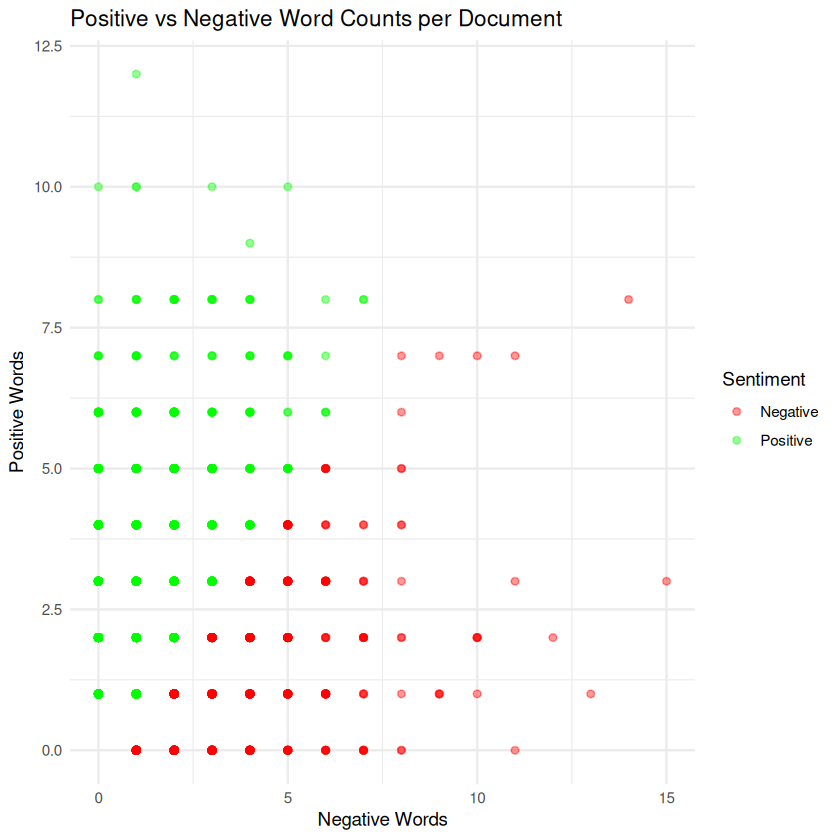

In [21]:
#Sentiment scatterplot (compare positive vs negative)
ggplot(MFL_text_sentiment, 
       aes(
           x = negative, 
           y = positive, 
           color = sentiment_score>= 0)) +
  geom_point(alpha = 0.4) +
  scale_color_manual(
      values = c("TRUE" = "green", "FALSE" = "red"),
      labels = c("Negative", "Positive"),
      name = "Sentiment")+
  labs(
    title = "Positive vs Negative Word Counts per Document",
    x = "Negative Words",
    y = "Positive Words"
  ) +
  theme_minimal()




	Paired t-test

data:  MFL_text_sentiment$positive and MFL_text_sentiment$negative
t = 9.1344, df = 3988, p-value < 2.2e-16
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 0.2403940 0.3717895
sample estimates:
mean difference 
      0.3060918 


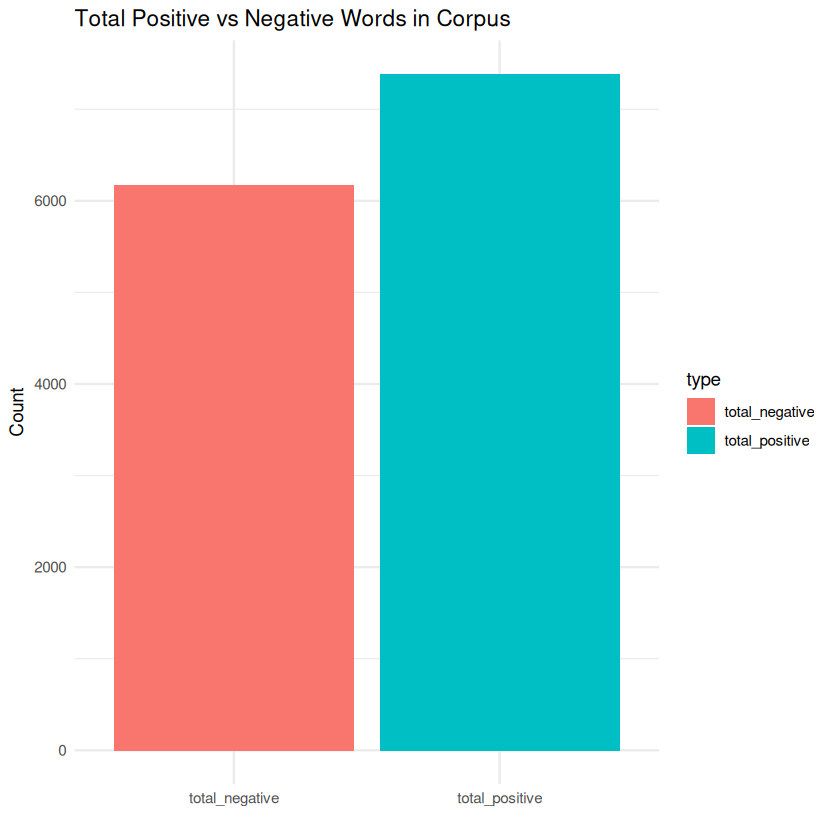

In [22]:
#Barchart of positive v negative words in corpus 
MFL_text_sentiment %>%
  summarise(
    total_positive = sum(positive),
    total_negative = sum(negative)
  ) %>%
  pivot_longer(everything(), names_to = "type", values_to = "count") %>%
  ggplot(aes(x = type, y = count, fill = type)) +
  geom_col() +
  labs(
    title = "Total Positive vs Negative Words in Corpus",
    x = "",
    y = "Count"
  ) +
  theme_minimal()

sentiment_ttest <- t.test(
  MFL_text_sentiment$positive,
  MFL_text_sentiment$negative,
  paired = TRUE
)

sentiment_ttest



    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-12.0000  -1.0000   0.0000   0.3061   1.0000  11.0000 

[1] -0.226414

[1] 5.08512

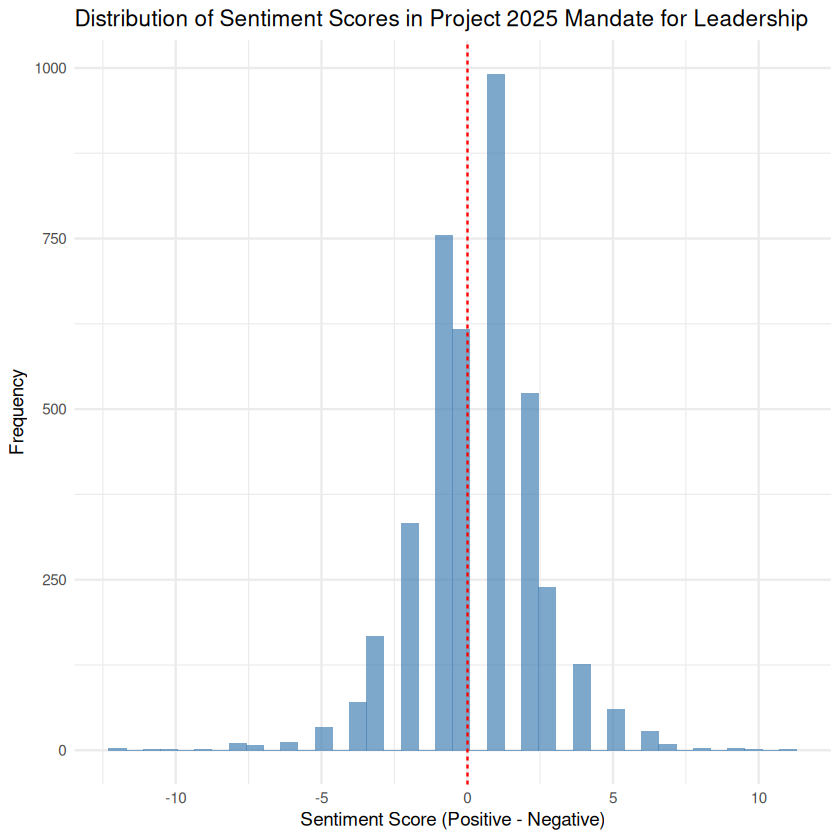

In [23]:
# Add sentiment back to original documents
MFL_text_with_sentiment <- MFL_text_sentiment %>%
  replace_na(list(positive = 0, negative = 0, sentiment_score = 0))

#Compute skewness and kurtosis
summary(MFL_text_with_sentiment$sentiment_score)
skewness(MFL_text_with_sentiment$sentiment_score)
kurtosis(MFL_text_with_sentiment$sentiment_score)

# Create a histogram of sentiment scores
ggplot(MFL_text_with_sentiment, aes(x = sentiment_score)) +     
  geom_histogram (bins=40, fill = "steelblue", alpha = 0.7) + 
  geom_vline(xintercept = 0, color = "red", linetype = "dashed") +
  labs(title = "Distribution of Sentiment Scores in Project 2025 Mandate for Leadership",
       x = "Sentiment Score (Positive - Negative)",
       y = "Frequency") +
  theme_minimal()





**Extreme sentiments found across 'Women's Health' (WH), 'Environmental' (ENV), or the INTERSECTION of these categories**

**Method** Using keywords defined during document classification, I extract document_ids from tokenized text that contain keywords from each category (WH, ENV, INTERSECTION), create a sentiment table for each category, identify the most emotionally charged text in each category by computing emotional text, and extract and label each word with a sentiment by joining words with the Bing lexicon.

The output likely reflects the authors' priorities around each category. Extreme sentiments for WH, for instance, centered around criticism of the FACE Act, a law preventing obstruction of access to abortion clinics, rather than, for example, the more pressing issue of maternal mortality in the United States.  Extreme sentiments for ENV focus on the impact of environmental regulation on the economy, but lack any emphasis, for example, on the cost of environmental impact on maternal health. Extreme sentiments at the intersection of WH and ENV focused again on the injustice of the FACE Act. This analysis enabled access to textual examples of what was previously quantified. 

**References**
Course 4, Module 13, Lesson 2: "Text Analysis for Environmental Data" by Luke Sanford — Covers cleaning, tokenization, stop-word removal, word-frequency analysis, sentiment analysis, building custom dictionaries, and visualizations


In [24]:
MFL_womens_health_docs <- MFL_text_tokens %>%
  filter(word %in% wh_keywords) %>%
  distinct(document_id)

MFL_womens_health_sentiment <- MFL_text_with_sentiment %>%
  filter(document_id %in% MFL_womens_health_docs$document_id)

MFL_most_emotional_WH <- MFL_womens_health_sentiment %>%
  mutate(total_sentiment_words = positive + negative) %>%
  arrange(desc(total_sentiment_words)) %>%
  slice_head(n = 1)

MFL_WH_tokens <- MFL_text_tokens %>%
  filter(document_id == MFL_most_emotional_WH$document_id) %>%
  left_join(bing_sentiment, by = "word") %>%
  mutate(sentiment = replace_na(sentiment, "neutral"))

MFL_WH_colored <- MFL_WH_tokens %>%
  mutate(colored_word = case_when(
    sentiment == "positive" ~ paste0("\033[32m", word, "\033[0m"),
    sentiment == "negative" ~ paste0("\033[31m", word, "\033[0m"),
    TRUE ~ word
  ))

cat(paste(MFL_WH_colored$colored_word, collapse = " "), "\n\n")

original_WH_text <- MFL_text_tbl %>%
  filter(document_id == MFL_most_emotional_WH$document_id) %>%
  pull(text)

cat(str_wrap(original_WH_text, width = 80))

abiding act administration attacks attempts basic biden branded care centers charging citizens collusion coordinated court covert dangerously decisions department diligently disfavored domestic double dozens election engaged evidence failed fbi formation hoax hunter ignoring immigration infused interference justice justices laptop law laws lost misinformation obligations operations parents partisan partisans political politically politicized pregnancy pretext prohibit propaganda prosecution protect racial republic russian shut speech standards suppression supreme terrorists threat unserious utterly violation violent 



The evidence shows that the Biden Administration s Department of Justice
has failed to protect law-abiding citizens and has ignored its most basic
obligations. It has become at once utterly unserious and dangerously
politicized. Prosecution and charging decisions are infused with racial and
partisan political double standards.20 Immigration laws are ignored.21 The FBI
harasses protesting parents (branded domestic terrorists by some partisans)
while working diligently to shut down politically disfavored speech on the
pretext of its being misinformation or disin formation. 22 A department that
prosecutes FACE Act cases while ignoring dozens of violent attacks on pregnancy
care centers and/or the coordinated violation of laws that prohibit attempts
to intimidate Supreme Court Justices by parading out side of their homes23 has
clearly lost its way. A department that has twice engaged in covert domestic
election interference and propaganda operations the Russian collusion hoax
in 2016 and t

In [25]:
MFL_environment_docs <- MFL_text_tokens %>%
  filter(word %in% env_keywords) %>%
  distinct(document_id)

MFL_environment_sentiment <- MFL_text_with_sentiment %>%
  filter(document_id %in% MFL_environment_docs$document_id)

MFL_most_emotional_ENV <- MFL_environment_sentiment %>%
  mutate(total_sentiment_words = positive + negative) %>%
  arrange(desc(total_sentiment_words)) %>%
  slice_head(n = 1)

MFL_ENV_tokens <- MFL_text_tokens %>%
  filter(document_id == MFL_most_emotional_ENV$document_id) %>%
  left_join(bing_sentiment, by = "word") %>%
  mutate(sentiment = replace_na(sentiment, "neutral"))

MFL_ENV_colored <- MFL_ENV_tokens %>%
  mutate(colored_word = case_when(
    sentiment == "positive" ~ paste0("\033[32m", word, "\033[0m"),
    sentiment == "negative" ~ paste0("\033[31m", word, "\033[0m"),
    TRUE ~ word
  ))

cat(paste(MFL_ENV_colored$colored_word, collapse = " "), "\n\n")

original_ENV_text <- MFL_text_tbl %>%
  filter(document_id == MFL_most_emotional_ENV$document_id) %>%
  pull(text)

cat(str_wrap(original_ENV_text, width = 80))

accepting actions activism actual agency american analytics attributable based biden change choice choose climate communities community costs creating diminished disregard economy effect enforcement environment environmental epa exorbitant false favored fear final generated growing harm harms healthy increased ineffective law led left liberty people perceived pertains positive private property public regulated regulations return rhetoric rights scare specifically story strong tangible threat tool trust uncertainty weighted 



Beyond creating such immediate and tangible harm in various communities, an
EPA led by activism and a disregard for the law has generated uncertainty in
the regulated community, vendetta-driven6 enforcement, weighted analytics,
increased costs, and diminished trust in final agency actions. Although the
U.S. environmental story is very positive, there has been a return to fear-based
rhetoric within the agency, especially as it pertains to the perceived threat of
climate change. Mischaracterizing the state of our environment generally and the
actual harms reasonably attributable to climate change specifically is a favored
tool that the Left uses to scare the American public into accepting their
ineffective, liberty-crushing regulations, diminished private property rights,
and exorbitant costs. In effect, the Biden EPA has once again presented a
false choice to the American people: that they have to choose between a healthy
environment and a strong, growing economy.

In [26]:
#Get intersection of document_ids
MFL_intersection_docs <- MFL_text_with_labels %>%
  filter(INTERSECTION==1) %>%
  #distinct(document_id)%>%
  pull(document_id)

MFL_most_emotional_intersection <- MFL_text_with_sentiment %>%
  filter(document_id %in% MFL_intersection_docs) %>%
  mutate(total_sentiment_words = positive + negative) %>%
  arrange(desc(total_sentiment_words)) %>%
  slice_head(n = 1)

#Tokens for those documents
MFL_intersection_tokens <- MFL_text_tokens %>%
  filter(document_id == MFL_most_emotional_intersection$document_id) %>%
  mutate(word = tolower(word)) %>%
  left_join(bing_sentiment, by = "word") %>%
  mutate(sentiment = replace_na(sentiment, "neutral"))

MFL_intersection_colored <- MFL_intersection_tokens %>%
  mutate(colored_word = case_when(
    sentiment == "positive" ~ paste0("\033[32m", word, "\033[0m"),
    sentiment == "negative" ~ paste0("\033[31m", word, "\033[0m"),
    TRUE ~ word
  ))

cat(paste(MFL_intersection_colored$colored_word, collapse = " "), "\n\n")

original_intersection_text <- MFL_text_tbl %>%
  filter(document_id == MFL_most_emotional_intersection$document_id) %>%
  pull(text)

cat(str_wrap(original_intersection_text, width = 80))

abiding act administration attacks attempts basic biden branded care centers charging citizens collusion coordinated court covert dangerously decisions department diligently disfavored domestic double dozens election engaged evidence failed fbi formation hoax hunter ignoring immigration infused interference justice justices laptop law laws lost misinformation obligations operations parents partisan partisans political politically politicized pregnancy pretext prohibit propaganda prosecution protect racial republic russian shut speech standards suppression supreme terrorists threat unserious utterly violation violent 



The evidence shows that the Biden Administration s Department of Justice
has failed to protect law-abiding citizens and has ignored its most basic
obligations. It has become at once utterly unserious and dangerously
politicized. Prosecution and charging decisions are infused with racial and
partisan political double standards.20 Immigration laws are ignored.21 The FBI
harasses protesting parents (branded domestic terrorists by some partisans)
while working diligently to shut down politically disfavored speech on the
pretext of its being misinformation or disin formation. 22 A department that
prosecutes FACE Act cases while ignoring dozens of violent attacks on pregnancy
care centers and/or the coordinated violation of laws that prohibit attempts
to intimidate Supreme Court Justices by parading out side of their homes23 has
clearly lost its way. A department that has twice engaged in covert domestic
election interference and propaganda operations the Russian collusion hoax
in 2016 and t

**Dictionary building and term count**

**Method** To compute tokens within dictionary categories, I built a dictionary inspired by the code along notebook for Module 4. I chose keywords relevant to WH, ENV, and INTERSECTION, tagged each token in the corpus, and counted tokens in each document. This represents a content-analysis workflow that provides a sense of the concepts represented in the corpus. For example, text 'impact' and 'solution' dictionary categories are least represented.

**References**
Course 4, Module 13, Lesson 2: "Text Analysis for Environmental Data" by Luke Sanford — Covers cleaning, tokenization, stop-word removal, word-frequency analysis, sentiment analysis, building custom dictionaries, and visualizations


In [27]:
# Create environmental reproductive health-related dictionaries containing relevant terms

health_dict <- list(

reproduction_terms = 
    c("pollution", "pollutant", "toxin", "toxic", "chemical", "pesticide", "herbicide", "contaminant", "contamination","lead", "mercury", "arsenic", "particulate", "pm25", "smog", "ozone","microplastic", "endocrine", "disruptor", "heat", "heatwave", "wildfire", "smoke", "drought", "flooding", "hurricane", "disaster", "climate", "warming", "extreme", "stressor", "water", "air", "soil", "sanitation", "hygiene", "sewage","infrastructure", "contamination", "quality", "hazard", "waste","pregnancy", "prenatal","perinatal","postpartum", "fertility", "miscarriage", "abortion", "termination", "stillbirth","birth", "labor","maternal","infant", "neonatal", "development", "fetus","embryo", "fetal", "conceptus", "premature","preterm", "hypertension", "preeclampsia"),
  
action_terms = 
    c("mandate", "policy", "agreement", "target", "reduction", "mitigation", "enforcement", "monitoring"),

impact_terms = 
    c("impact", "effect", "damage", "efficiency", "crisis", "emergency", "decline"),
  
solution_terms = 
    c("solution", "eliminate", "strengthen", "marriage", "prohibit", "decentralize", "deregulate", "monitor", "investigate", "defund", "population", "restrict", "reform", "enforce"),
  
policy_terms = 
    c("executive", "reform", "oversight", "enforcement", "agency", "regulation"),
  
sector_terms = 
    c("faith", "family", "federal", "local", "government", "epa", "nih", "church", "state")
)

# Categorize tokens in categories based on dictionary
repro_analysis <- MFL_text_tokens %>%
  mutate(
    reproduction_related = word %in% health_dict$reproduction_terms,
    action_related = word %in% health_dict$action_terms,
    impact_related = word %in% health_dict$impact_terms,
    solution_related = word %in% health_dict$solution_terms,
    policy_related = word %in% health_dict$policy_terms,
    sector_related = word %in% health_dict$sector_terms
  ) %>%
 
#Count by grouping by document_ids and summarize counts for each category

group_by(document_id) %>%
  summarise(
    reproduction_count = sum(reproduction_related),
    action_count = sum(action_related),
    impact_count = sum(impact_related),
    solution_count = sum(solution_related),
    policy_count = sum(policy_related),  
    sector_count = sum(sector_related)  
  )

# Display summary
repro_analysis %>%
  summarise(
    total_reproduction = sum(reproduction_count),
    total_action = sum(action_count),
    total_impact = sum(impact_count),
    total_solution = sum(solution_count),
    total_policy = sum(policy_count),  
    total_sector = sum(sector_count)  
  ) %>%
  gather(category, count) %>%
  kable( col.names = c("Category", "Total Count"))

library(tidyverse)

health_table <- enframe(health_dict, name = "category", value = "terms") %>%
  unnest(terms)

health_table_indexed <- health_table %>%
  group_by(category) %>%
  mutate(row = row_number()) %>%
  ungroup()

health_table_wide <- health_table_indexed %>%
  pivot_wider(
    names_from = category,
    values_from = terms
  )

#A reminder of category keywords
health_table_wide




|Category           | Total Count|
|:------------------|-----------:|
|total_reproduction |        1119|
|total_action       |         934|
|total_impact       |         302|
|total_solution     |         573|
|total_policy       |        1081|
|total_sector       |        1642|

row,reproduction_terms,action_terms,impact_terms,solution_terms,policy_terms,sector_terms
<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,pollution,mandate,impact,solution,executive,faith
2,pollutant,policy,effect,eliminate,reform,family
3,toxin,agreement,damage,strengthen,oversight,federal
4,toxic,target,efficiency,marriage,enforcement,local
5,chemical,reduction,crisis,prohibit,agency,government
6,pesticide,mitigation,emergency,decentralize,regulation,epa
7,herbicide,enforcement,decline,deregulate,NA,nih
8,contaminant,monitoring,NA,monitor,NA,church
9,contamination,NA,NA,investigate,NA,state


**Data visualization**

**Method** I use a bar chart to illustrate prevalence of concepts across the corpus. One observation is that there is an over-emphasis of text related to sectors (i.e. institutions) and a pausity of 'action'- and 'solution'-oriented text.

**References**Course 1, Module 4: "Basic Data Visualization" by Andie Creel — Introduces plotting in R using box plots, bar charts, scatter plots, and multiple plot layouts

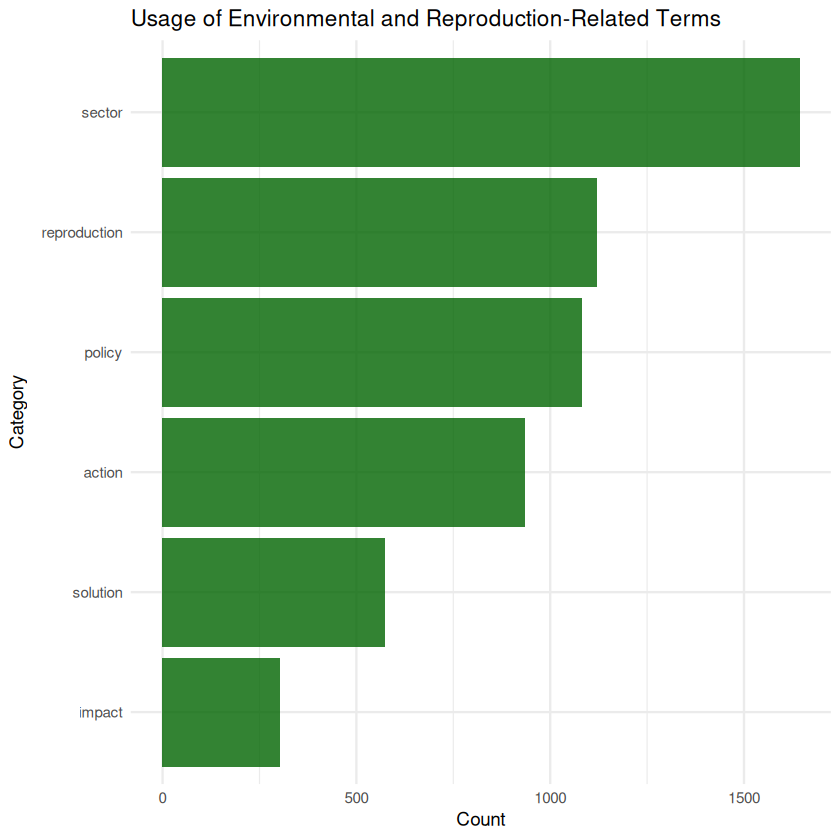

In [28]:
# Visualize environment and reproduction-related term usage
repro_analysis %>%
  summarise(
    reproduction = sum(reproduction_count),
    action = sum(action_count),
    impact = sum(impact_count),
    solution = sum(solution_count),
    policy = sum(policy_count),  
    sector = sum(sector_count),  
  ) %>%
  gather(category, count) %>%
  ggplot(aes(x = reorder(category, count), y = count)) +
  geom_col(fill = "darkgreen", alpha = 0.8) +
  coord_flip() +
  labs(title = "Usage of Environmental and Reproduction-Related Terms",
       x = "Category",
       y = "Count") +
  theme_minimal()

**Joining dictionary counts with sentiment scores**

**Method** I examined how environmental reproductive health themes relate to the document's tone.  This involves joining environmental reproductive health terms with average sentiment for each document and document category labels (e.g. ENV, WH, INTERSECTION). Next, I created six document subsets representing conceptual themes that would be expected in a policy text (e.g., reproduction, action, impact, solution, sector). Sentiment was computed for each theme to better understand commonalities among themes and to determine the extent to which documents are negative or positive. 

Curiously, the analysis reveals that documents containing environmental reproductive health terms were a large part of the corpus, which likely indicates that characterization of text was overly promiscuous and may not actually reflect the corpus. This artifact may stem from an especially long list of keywords in the reproduction category which created more opportunity for commonalities.  The 'sector' category, which includes the keywords 'government', 'EPA', 'NIH', 'church', and 'state', was considered the largest category. With the exception of the 'impact' category, documents in all categories were deemed positive in tone. Documents discussing 'impact', however, were strongly negative, which may reflect the extreme sentiment scores observed in earlier analyses.

**References**
Course 4, Module 13, Lesson 2: "Text Analysis for Environmental Data" by Luke Sanford — Covers cleaning, tokenization, stop-word removal, word-frequency analysis, sentiment analysis, building custom dictionaries, and visualizations

Course 2, Module 5: "Data Manipulation with Tidyverse" by Andie Creel — Dataset integration and reshaping using the tidyr package and dplyr functions

In [29]:
# Combine environment/reproduction analysis with sentiment analysis

# Add labels back to our sentiment analysis 
MFL_sentiment_analysis <- repro_analysis %>%
  left_join(
    MFL_text_sentiment %>%
      group_by(document_id) %>%
      summarise(avg_sentiment = mean(sentiment_score, na.rm = TRUE)),
    by = "document_id"
  ) %>%
  left_join(
    MFL_text_with_labels %>% 
      select(document_id, ENV, WH, INTERSECTION),
    by = "document_id"
  )


# Create separate datasets for each category based on term presence
reproduction_docs <- MFL_sentiment_analysis %>% filter(reproduction_count > 0)
action_docs <- MFL_sentiment_analysis %>% filter (action_count > 0)
impact_docs <- MFL_sentiment_analysis %>% filter(impact_count > 0)
solution_docs <- MFL_sentiment_analysis %>% filter(solution_count > 0)
policy_docs <- MFL_sentiment_analysis %>% filter(policy_count > 0)
sector_docs <- MFL_sentiment_analysis %>% filter (sector_count > 0)

# Calculate sentiment for each category
category_sentiment <- tibble(
    category = c("reproduction", "action", "impact", "solution", "policy", "sector"),
    documents = c(nrow(reproduction_docs), nrow(action_docs), nrow(impact_docs), 
    nrow(solution_docs), nrow(policy_docs), nrow(sector_docs)
    ),
    avg_sentiment =c(
        mean(reproduction_docs$avg_sentiment, na.rm=TRUE),
        mean(action_docs$avg_sentiment, na.rm=TRUE),
        mean(impact_docs$avg_sentiment, na.rm=TRUE),
        mean(solution_docs$avg_sentiment, na.rm=TRUE),
        mean(policy_docs$avg_sentiment, na.rm=TRUE),
        mean(sector_docs$avg_sentiment, na.rm=TRUE)            
    )
)

# Display summary of environment terms and sentiment
category_sentiment %>%
  kable(col.names = c("Category", "Document Count", "Average Sentiment")
       )




|Category     | Document Count| Average Sentiment|
|:------------|--------------:|-----------------:|
|reproduction |            930|         0.3127273|
|action       |            865|         0.3450980|
|impact       |            289|        -0.4259259|
|solution     |            542|         0.4919028|
|policy       |            942|         0.4334112|
|sector       |           1274|         0.3403880|

**Data visualization** I used a bubble plot to show the average sentiment of keywords in each category.

**References** Course 5, Module 17, Lesson 4: "Customizing Data Visualizations" by Simon Queenborough — Visualizations in Google Sheets, base R, and ggplot2;  customization of colors, axes, titles, and annotations, and discusses choosing visualization

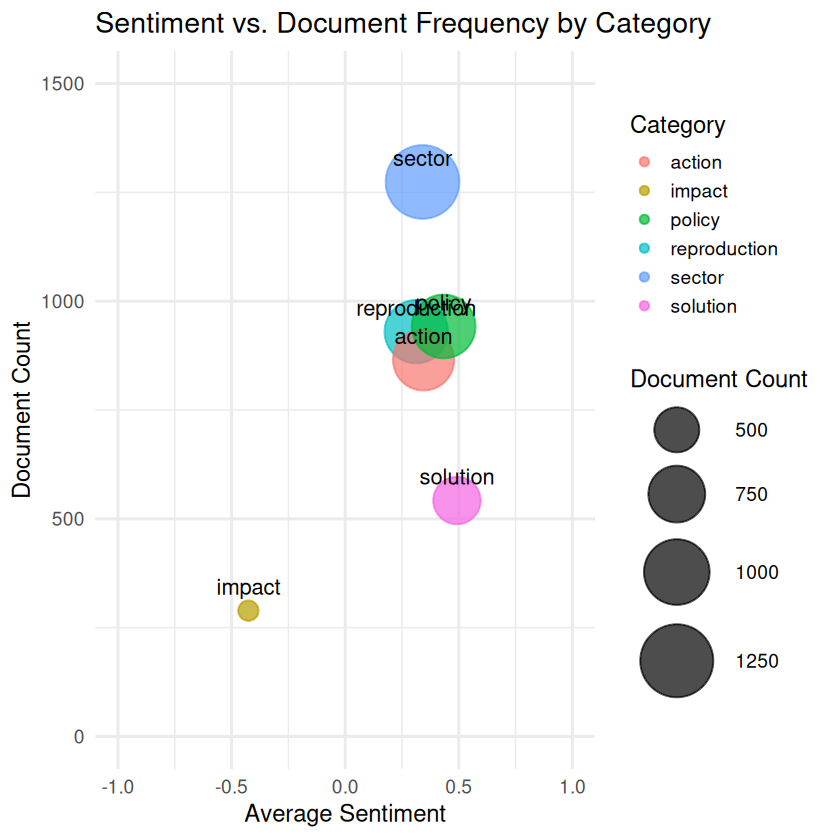

In [30]:
#Bubble plot

ggplot(category_sentiment, 
       aes(x = avg_sentiment, 
           y = documents, 
           size = documents, 
           color = category)) +
  geom_point(alpha = 0.7) +
  geom_text(aes(label = category), 
            vjust = -1, 
            size = 4.5,
            color="black")+
xlim(-1, 1)+
ylim(0, 1500)+
guides(color = guide_legend(override.aes = list(label = ""))) +
scale_size_continuous(range = c(5, 20)) +
  labs(
    title = "Sentiment vs. Document Frequency by Category",
    x = "Average Sentiment",
    y = "Document Count",
    size = "Document Count",
    color = "Category"
  ) +
  theme_minimal(base_size = 14)


**Using TF-IDF to identify unique, document-specific language **

**Method** I provide a pipeline for understanding terms that characterize the uniqueness of each document. I compute TF-IDF for raw and stemmed words, merge TF-IDF with document labels, and also identify vocabulary for each category (ENV, WH, INTERSECTION).

**Results** Top TF-IDF stems represent terms which are unique, rare, and document-specific terms. Among these top terms are proper nouns, words that structure paragraphs (e.g., background, introduction, conclusion), and technical topics that may reflect specific policy areas.

Category-specific TF-IDF results for ENV, WH, and INTERSECTION categories reveal targeted word patterns and I used AI to characterize average TF-IDF output for each category. The ENV category is rich in acronyms, technical language, and geographical areas with high TF-IDF values, which signals category specificity. The WH category contains terms which might be associated with legal language, critique, gender identity, and policy. The INTERSECTION category, which reflects language patterns at the intersection of WH and ENV, contains words that suggest challenge, threat, and skepticism.

**References** Course 4, Module 13, Lesson 4: "TF-IDF and Topic Models for Environmental Text Analysis" by Luke Sanford —Covers stemming, document-term matrices, Document-Term Matrices (DTM) construction, TF-IDF weight computation, and model fitting using (Latent Dirichlet Allocation) LDA

In [31]:
# Calculate TF-IDF scores and count words in each document
MFL_tf_idf <- MFL_text_tokens %>%
  count(document_id, word, sort = TRUE) %>%
  bind_tf_idf(word, document_id, n)

# Look at highest TF-IDF scores to determine important words
MFL_tf_idf %>%
  arrange(desc(tf_idf)) %>%
  head(20) %>%
  kable(col.names = c("Document ID", "Word", "Count", "TF", "IDF", "TF-IDF"))



| Document ID|Word         | Count| TF|      IDF|   TF-IDF|
|-----------:|:------------|-----:|--:|--------:|--------:|
|        8463|hazelton     |     1|  1| 7.871883| 7.871883|
|        8957|warren       |     1|  1| 7.178736| 7.178736|
|        7272|introduction |     1|  1| 6.955593| 6.955593|
|        9741|onward       |     1|  1| 6.955593| 6.955593|
|        2684|mike         |     1|  1| 6.773271| 6.773271|
|        4949|radiation    |     1|  1| 6.773271| 6.773271|
|        2092|ship         |     1|  1| 6.367806| 6.367806|
|        6794|religion     |     1|  1| 6.167135| 6.167135|
|        8636|budgetary    |     1|  1| 6.167135| 6.167135|
|        9599|april        |     1|  1| 6.167135| 6.167135|
|        9605|april        |     1|  1| 6.167135| 6.167135|
|        8417|background   |     1|  1| 6.080124| 6.080124|
|        9351|cftc         |     1|  1| 6.080124| 6.080124|
|        2276|conclusion   |     1|  1| 5.674659| 5.674659|
|        2678|conclusion   |     1|  1

In [32]:
# Calculate TF-IDF using word stems
MFL_stem_tfidf <- MFL_text_tokens %>%
  mutate(word_stem = SnowballC::wordStem(word))%>%
  count(document_id, word_stem, sort = TRUE) %>%
  bind_tf_idf(word_stem, document_id,  n)

# Display top TF-IDF terms
cat("Top TF-IDF terms in Mandate For Leadership:\n")

MFL_stem_tfidf %>%
  arrange(desc(tf_idf)) %>%
  head(20) %>%
  select(document_id, word_stem, n, tf_idf) %>%
  kable(col.names = c("Document_ID", "Word_Stem", "n", "TF-IDF")
       )

Top TF-IDF terms in Mandate For Leadership:




| Document_ID|Word_Stem  |  n|   TF-IDF|
|-----------:|:----------|--:|--------:|
|        8463|hazelton   |  1| 7.871883|
|        8957|warren     |  1| 7.178736|
|        7272|introduct  |  1| 6.955593|
|        9741|onward     |  1| 6.955593|
|        2684|mike       |  1| 6.773271|
|        4949|radiat     |  1| 6.773271|
|        6794|religion   |  1| 6.167135|
|        8636|budgetari  |  1| 6.167135|
|        9599|april      |  1| 6.167135|
|        9605|april      |  1| 6.167135|
|        9351|cftc       |  1| 6.080124|
|        8417|background |  1| 5.674659|
|        2224|arctic     |  1| 5.620591|
|        6107|interior   |  1| 5.569298|
|        1065|navi       |  1| 5.473988|
|        2276|conclus    |  1| 5.473988|
|        2678|conclus    |  1| 5.473988|
|        2909|conclus    |  1| 5.473988|
|        3187|conclus    |  1| 5.473988|
|        5327|conclus    |  1| 5.473988|

In [33]:
#Join TF-IDF scores with document category labels to analyze within categories
tfidf_labeled <- MFL_stem_tfidf %>%
  left_join(
    MFL_text_with_labels %>% 
      select(document_id, ENV, WH, INTERSECTION),
    by = "document_id"
  )

#Assign documents to categories
tfidf_labeled <- tfidf_labeled %>%
  mutate(
    category = case_when(
      INTERSECTION ==1~ "Intersection",
      ENV == 1 ~ "Environmental",
      WH== 1 ~ "Women's Health",
      TRUE ~ "Neutral"
    )
  )

#Filter neutral documents
tfidf_labeled <- tfidf_labeled %>% 
  filter(category != "Neutral")


#Compute average TF-IDF within each category
tfidf_by_category <- tfidf_labeled %>%
  group_by(category, word_stem) %>%
  summarise(
    avg_tfidf = mean(tf_idf, na.rm = TRUE),
    .groups = "drop"
  )

#Extract top TF-IDF stems/category
top_terms_by_category <- tfidf_by_category %>%
  group_by(category) %>%
  slice_max(avg_tfidf, n = 20) %>%
  arrange(category, desc(avg_tfidf))
top_terms_by_category %>%
  
kable(col.names = c("Category", "Word Stem", "Avg TF-IDF"))




|Category       |Word Stem   | Avg TF-IDF|
|:--------------|:-----------|----------:|
|Environmental  |aspr        |  1.5743767|
|Environmental  |ser         |  1.1288785|
|Environmental  |pfa         |  1.1245548|
|Environmental  |ato         |  1.0735621|
|Environmental  |columbia    |  0.9265127|
|Environmental  |ceq         |  0.8949896|
|Environmental  |eta         |  0.8296020|
|Environmental  |rmo         |  0.7976374|
|Environmental  |prp         |  0.7871883|
|Environmental  |ambient     |  0.7623671|
|Environmental  |lowest      |  0.7600155|
|Environmental  |ocspp       |  0.7595677|
|Environmental  |commenc     |  0.7525857|
|Environmental  |pad         |  0.7525857|
|Environmental  |inject      |  0.7178736|
|Environmental  |osrti       |  0.7156258|
|Environmental  |predic      |  0.6955593|
|Environmental  |hijack      |  0.6789983|
|Environmental  |convert     |  0.6787653|
|Environmental  |munit       |  0.6741697|
|Intersection   |woke        |  0.3920531|
|Intersec

**Data visualization** I depicted Top TF-IDF Terms by Category in a faceted bar chart.

**References** Course 1, Module 4: "Basic Data Visualization" by Andie Creel — Introduces plotting in R using box plots, bar charts, scatter plots, and multiple plot layouts

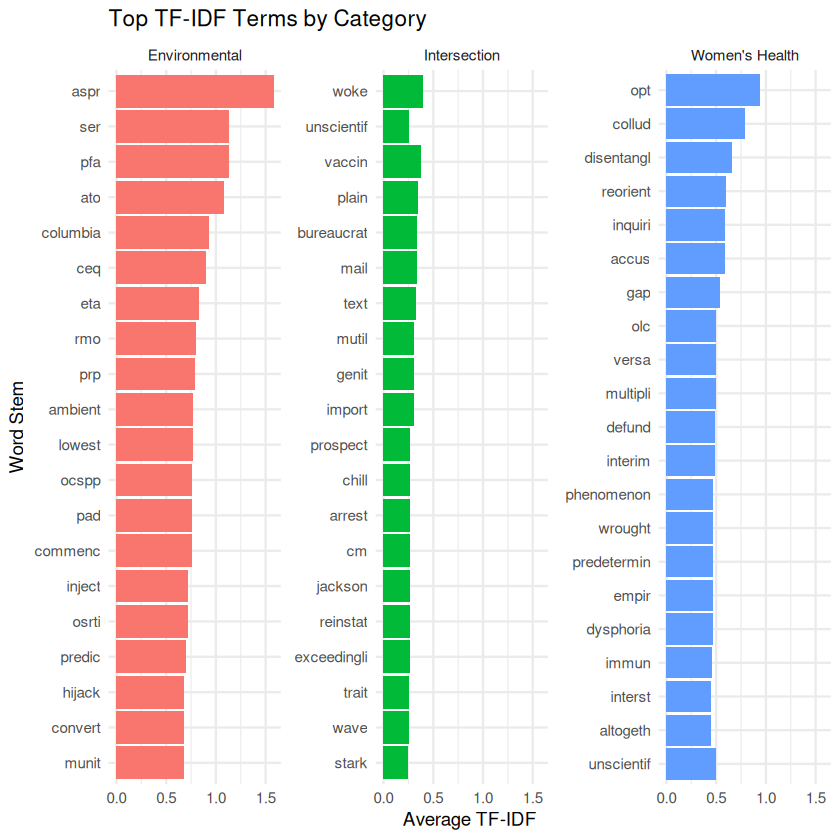

In [34]:
ggplot(top_terms_by_category, 
       aes(x = reorder(word_stem, avg_tfidf), y = avg_tfidf, fill = category)) +
  geom_col(show.legend = FALSE) +
  coord_flip() +
  facet_wrap(~ category, scales = "free_y") +
  labs(
    title = "Top TF-IDF Terms by Category",
    x = "Word Stem",
    y = "Average TF-IDF"
  ) +
  theme_minimal()

**Term frequency and topic modeling preprocessing**

**Method** I counted term and document frequencies and built a Document -Term Matrix (DTM) for supervised LDA modeling, which provides insight into themes emerging from documents. This required filtering extremely rare terms and assuring that the matrix was populated correctly.

**Results** Term and document frequencies are similar suggesting that terms are one-off or extremely rare and, therefore, less likely to generate a robust LDA model.

**References** Course 4, Module 13, Lesson 4: "TF-IDF and Topic Models for Environmental Text Analysis" by Luke Sanford —Covers stemming, document-term matrices, Document-Term Matrices (DTM) construction, TF-IDF weight computation, and model fitting using (Latent Dirichlet Allocation) LDA

In [35]:
#Term frequencies to identify common and uncommon words
MFL_term_frequencies <- MFL_text_tokens %>%
  count(word_stem, sort = TRUE)

# Calculate document frequencies (how many documents each term appears in)
MFL_doc_frequencies <- MFL_text_tokens %>%
  distinct(document_id, word_stem) %>%
  count(word_stem, sort = TRUE)

# Get total number of documents
MFL_total_docs <- MFL_text_tokens %>%
  distinct(document_id) %>%
  nrow()

# Filter out very common words (appearing in >80% of documents) and very rare words (appearing in <2 documents)
MFL_filtered_terms <- MFL_text_tokens %>%
  count(word_stem) %>%
  filter(n <= (MFL_total_docs * 0.8)) %>%
  pull(word_stem)

# Create Document-Term Matrix (DTM) for topic modeling
MFL_dtm <- MFL_text_tokens %>%
  filter(word_stem %in% MFL_filtered_terms) %>%
  count(document_id, word_stem) %>%
  cast_dtm(document_id, word_stem, n)

# Examine the DTM
cat("Original vocabulary size:", nrow(MFL_term_frequencies), "\n")
cat("Filtered vocabulary size:", length(MFL_filtered_terms), "\n")
cat("DTM dimensions:", dim(MFL_dtm), "\n")
cat("Number of documents:", nrow(MFL_dtm), "\n")
cat("Number of terms:", ncol(MFL_dtm), "\n")

# Look at the first few terms and documents to make certain that the matrix is populated as expected
inspect(MFL_dtm[1:5, 1:10])


Original vocabulary size: 5350 


Filtered vocabulary size: 5350 


DTM dimensions: 5245 5350 


Number of documents: 5245 


Number of terms: 5350 


<<DocumentTermMatrix (documents: 5, terms: 10)>>
Non-/sparse entries: 13/37
Sparsity           : 74%
Maximal term length: 9
Weighting          : term frequency (tf)
Sample             :
    Terms
Docs acut adrift adversari ago america besieg betrai conserv dedic dire
   2    1      1         1   1       1      1      1       1     1    1
   3    0      0         0   0       1      0      0       1     0    0
   4    0      0         0   0       0      0      0       0     0    0
   5    0      0         0   0       0      0      0       1     0    0
   6    0      0         0   0       0      0      0       0     0    0


**Data visualization**  I depicted term and document word stem frequencies in bar charts.

**References** Course 1, Module 4: "Basic Data Visualization" by Andie Creel — Introduces plotting in R using box plots, bar charts, scatter plots, and multiple plot layouts

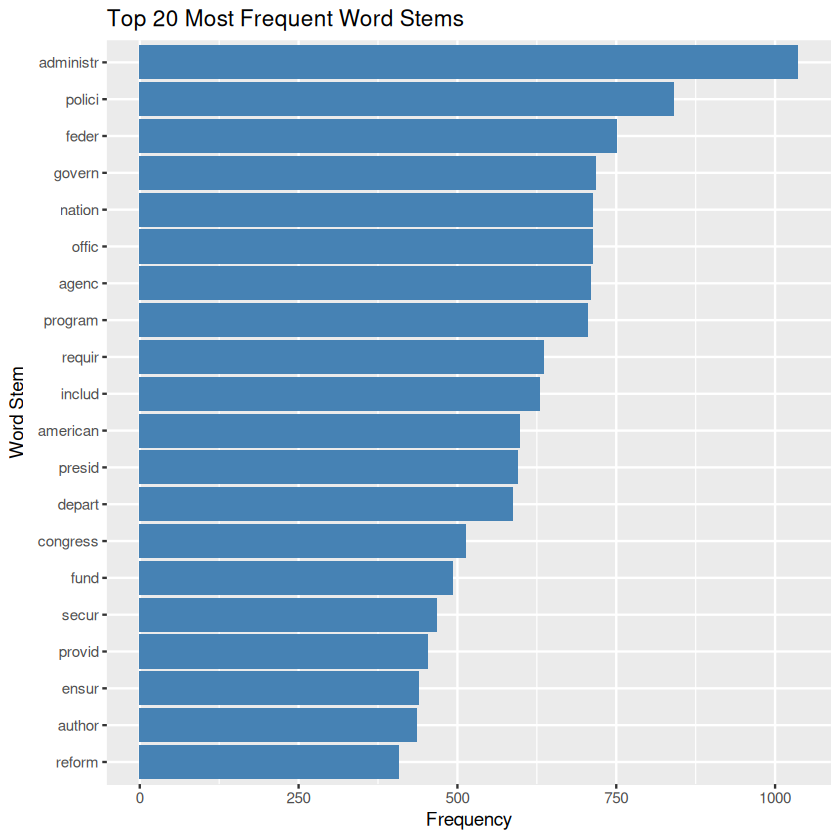

In [36]:
MFL_term_frequencies %>%
  slice_max(n, n = 20) %>%
  ggplot(aes(x = reorder(word_stem, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 20 Most Frequent Word Stems",
       x = "Word Stem",
       y = "Frequency")

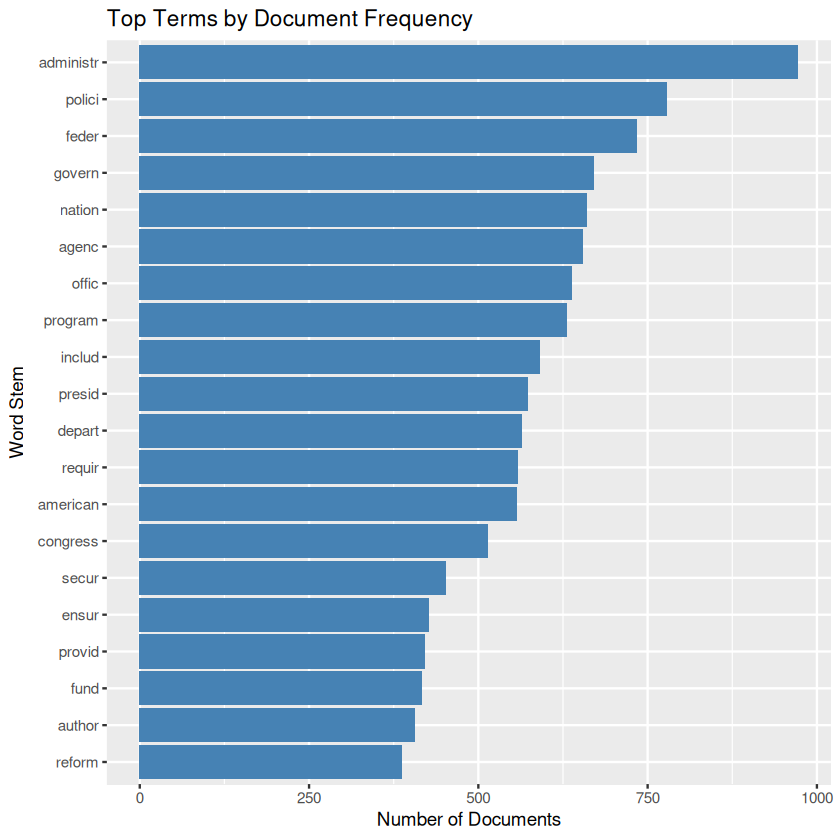

In [37]:
MFL_doc_frequencies %>%
  slice_max(n, n = 20) %>%
  ggplot(aes(x = reorder(word_stem, n), y = n)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top Terms by Document Frequency",
       x = "Word Stem",
       y = "Number of Documents")

**Latent Dirichlet Allocation(LDA) topic modeling**

**Method** To create an unsupervised topic model to predict non-obvious themes across the corpus, I cleaned and filtered terms, built matrices (DTMs), fit LDA models with different topics, extracted terms, computed TF-IDF and joined theTF-IDF matrix with document labels, extracted lasso coefficients, filtered zero coefficients, and performed multinomial logistic regression to identify top predicted words.

**Results** As described previously, the similarities between term and document frequencies suggests that this corpus is not amenable to an unsupervised model such as LDA. Although this corpus may be more appropriate for a supervised model that classifies or categorizes documents, I attempt LDA topic modeling to predict themes across categories (ENV, WH, INTERSECTION). Using a combination of data visualization and AI to categorize terms and their respective lasso coefficients, I discovered that terms in the ENV category have large negative coefficients suggesting that the corpus is unlikely to be classified as 'Environmental'. The strongest coefficients occur in the WH and INTERSECTION categories where WH language has a social-policy and medical framing and INTERSECTION language uses more ideological and legal language. These predictions may imply that there is a policy disconnect between Environmental (ENV) and Women's Health (WH) in Project 2025 'Mandate for Leadership'. Instead, language predictions about the INTERSECTION (ENV + WH) category suggest that any policy connecting ENV and WH focuses on ideological and politically movtivated topics and not the intersection between environmental health and women's health.

**References** Course 4, Module 13, Lesson 4: "TF-IDF and Topic Models for Environmental Text Analysis" by Luke Sanford —Covers stemming, document-term matrices, Document-Term Matrices (DTM) construction, TF-IDF weight computation, and model fitting using (Latent Dirichlet Allocation) LDA

Course 4, Module 13, Lesson 5: "Supervised Learning with Text" by Luke Sanford —Introduces how labeled text examples can train models using features like bag-of-words, TF-IDF, or topic proportions, covering common models, evaluation methods, and workflows for predicting labels on unlabeled texts

In [38]:
# Fit LDA model with 5 topics
set.seed(123)  # For reproducibility
MFL_lda <- LDA(MFL_dtm, k = 5, control = list(seed = 123)) #k is number of topics

# Extract the top terms for each topic
MFL_topics <- tidy(MFL_lda, matrix = "beta")

# Look at the top 10 terms for each topic
MFL_top_terms <- MFL_topics %>%
  group_by(topic) %>%
  top_n(10, beta) %>%
  ungroup() %>%
  arrange(topic, -beta)

# Display the results
MFL_top_terms %>%
  kable(col.names = c("Topic", "Term", "Beta (Probability)"))




| Topic|Term      | Beta (Probability)|
|-----:|:---------|------------------:|
|     1|depart    |          0.0107522|
|     1|govern    |          0.0089838|
|     1|nation    |          0.0077343|
|     1|administr |          0.0066205|
|     1|act       |          0.0065362|
|     1|includ    |          0.0063321|
|     1|secur     |          0.0061093|
|     1|develop   |          0.0060516|
|     1|enforc    |          0.0059858|
|     1|offic     |          0.0059365|
|     2|administr |          0.0148766|
|     2|american  |          0.0103867|
|     2|program   |          0.0084304|
|     2|includ    |          0.0076653|
|     2|govern    |          0.0072706|
|     2|provid    |          0.0066327|
|     2|fund      |          0.0066165|
|     2|polici    |          0.0063274|
|     2|regul     |          0.0062895|
|     2|offic     |          0.0051682|
|     3|feder     |          0.0136797|
|     3|polici    |          0.0118323|
|     3|effect    |          0.0086786

**Data visualization** I depicted Topic 10 Terms in 'hidden' topic categories in faceted bar charts (denoted 1-5).  For topic categorization, the list of top terms and their beta probabilities were entered into AI, which characterized hidden topic categories as follows:

*Topic 1:* Federal departments, Enforcement, and National Governance
*Topic 2:*  Programs, Funding, Regulation, and Public Administration
*Topic 3:* Federal Agencies, Requirements, and Policy Effects
*Topic 4:* Executive Policy Development and National Security
*Topic 5:* Public Service Delivery, Federal Requirements, and National Administration

**References** Course 1, Module 4: "Basic Data Visualization" by Andie Creel — Introduces plotting in R using box plots, bar charts, scatter plots, and multiple plot layouts


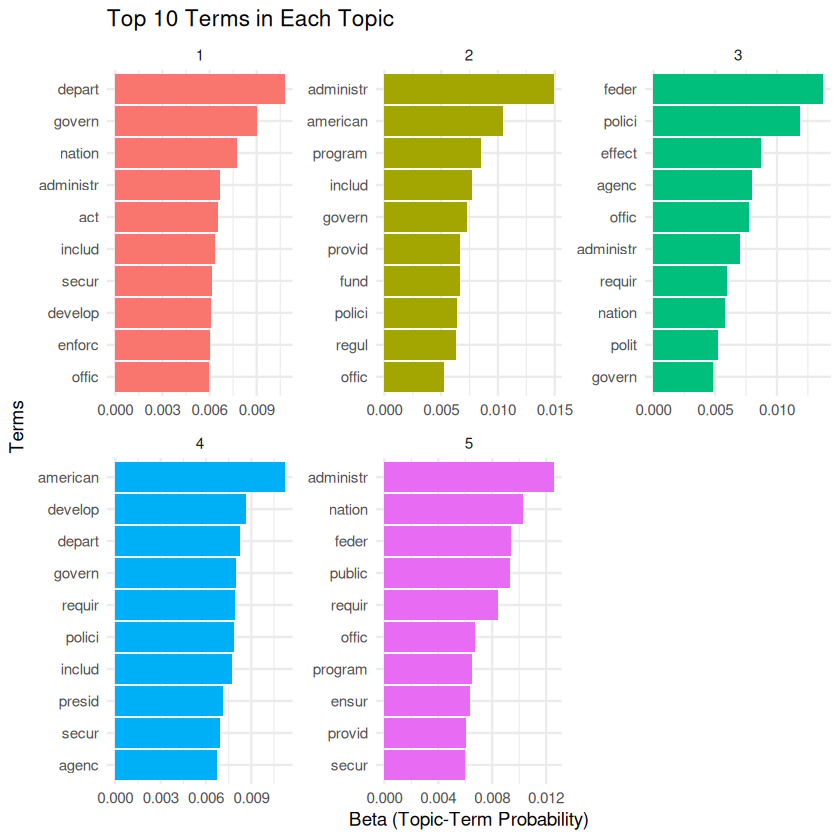

In [49]:
# Visualize the top terms for each topic
MFL_top_terms <- MFL_topics %>%
  group_by(topic) %>%
  top_n(10, beta) %>%
  ungroup() %>%
  arrange(topic, -beta)
MFL_top_terms %>%
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(term, beta, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  coord_flip() +
  scale_x_reordered() +
  labs(title = "Top 10 Terms in Each Topic",
       x = "Terms",
       y = "Beta (Topic-Term Probability)") +
  theme_minimal()



In [40]:
# Remove rare terms (appear in < 5 documents)
dfreq <- MFL_text_tokens %>%
  distinct(document_id, word) %>%
  count(word, name = "doc_freq")

vocab_keep <- dfreq %>%
  filter(doc_freq >= 5) %>%
  pull(word)

# Filter tokens
tokens_filtered <- MFL_text_tokens %>%
  filter(word %in% vocab_keep)

head(tokens_filtered, 3)

document_id,word,word_stem,n,tf,idf,tf_idf
<int>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>
2,acute,acut,1,0.02631579,6.955593,0.1830419
2,adversaries,adversari,1,0.02631579,4.521979,0.1189995
2,ago,ago,1,0.02631579,5.473988,0.1440523


In [41]:
# Build DTM for LDA
dtm_lda <- tokens_filtered %>%
  count(document_id, word) %>%
  cast_dtm(document_id, word, n)

MFL_lda <- LDA(dtm_lda, k = 10, control = list(seed = 123))

# Compute tf-idf
tf_idf <- MFL_text_tokens %>%
  count(document_id, word_stem) %>%
  bind_tf_idf(document_id, word_stem, n)

# Remove zero tf-idf terms
tfidf_filtered <- tf_idf %>%
  filter(tf_idf > 0)

head(tfidf_filtered, 3)

document_id,word_stem,n,tf,idf,tf_idf
<int>,<chr>,<int>,<dbl>,<dbl>,<dbl>
2,acut,1,0.20000000,4.947266,0.98945314
2,adrift,1,0.50000000,4.947266,2.47363284
2,adversari,1,0.01470588,4.947266,0.07275391


In [42]:

# Build tf-idf matrix for glmnet
dtm_glmnet <- tfidf_filtered %>%
  select(document_id, word_stem, tf_idf) %>%
  pivot_wider(
    names_from = word_stem,
    values_from = tf_idf,
    values_fill = 0
  )

# Extract labels from tfidf_labeled
labels <- tfidf_labeled %>%
  distinct(document_id, category)

# Join tf-idf matrix with labels
data_for_model <- dtm_glmnet %>%
  inner_join(labels, by = "document_id")

# Replace NA only in numeric columns
data_for_model <- data_for_model %>%
  mutate(across(where(is.numeric), ~ tidyr::replace_na(., 0)))

# Extract X and y
X <- data_for_model %>%
  select(-document_id, -category) %>%
  as.matrix()

y <- factor(data_for_model$category)

# Fit multinomial lasso
library(glmnet)

fit <- cv.glmnet(
  X, y,
  family = "multinomial",
  alpha = 1,
  type.measure = "class"
)

head(data_for_model, 3)

document_id,acut,adrift,adversari,ago,america,besieg,betrai,conserv,dedic,⋯,overenforc,sherman,taft,predica,alphabet,microsoft,onward,foreword,afterword,category
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
13,0,0,0,0,0,0,0,0.01706134,0,⋯,0,0,0,0,0,0,0,0,0,Environmental
14,0,0,0,0,0,0,0,0.03366165,0,⋯,0,0,0,0,0,0,0,0,0,Environmental
43,0,0,0,0,0,0,0,0.01579346,0,⋯,0,0,0,0,0,0,0,0,0,Women's Health


In [44]:

# Extract coefficients for each category
coefs <- coef(fit, s = "lambda.min")

# Convert to tidy tibble
coef_df <- map_df(
  names(coefs),
  ~ {
    mat <- coefs[[.x]]  # sparse matrix for this class
    tibble(
      term = rownames(mat),
      estimate = as.numeric(mat[, 1]),
      category = .x
    )
  }
)

# Remove intercept and zero coefficients
coef_df <- coef_df %>%
  filter(term != "(Intercept)") %>%
  filter(estimate != 0)

# Select top predictive words per category
top_words_by_category <- coef_df %>%
  group_by(category) %>%
  slice_max(abs(estimate), n = 10) %>%
  ungroup()

head(top_words_by_category, 25)


term,estimate,category
<chr>,<dbl>,<chr>
abort,-122.7739223,Environmental
women,-54.8553495,Environmental
pregnanc,-9.4882723,Environmental
hh,-5.2544368,Environmental
child,-3.3803807,Environmental
famili,-3.0625090,Environmental
father,-3.0209689,Environmental
mother,-1.7368171,Environmental
chill,-1.5323366,Environmental


**Data visualization** I depicted in a faceted box plot the Top Predictive Words across WH, ENV, and INTERSECTION categories based on lasso coefficients. A negative coefficient indicates that a term decreases the probability that a document belongs to a specific category. Positive coefficients increase that probability. A coefficient of zero eliminates the possibility that a word is used in the model.

**References** Course 1, Module 4: "Basic Data Visualization" by Andie Creel — Introduces plotting in R using box plots, bar charts, scatter plots, and multiple plot layouts

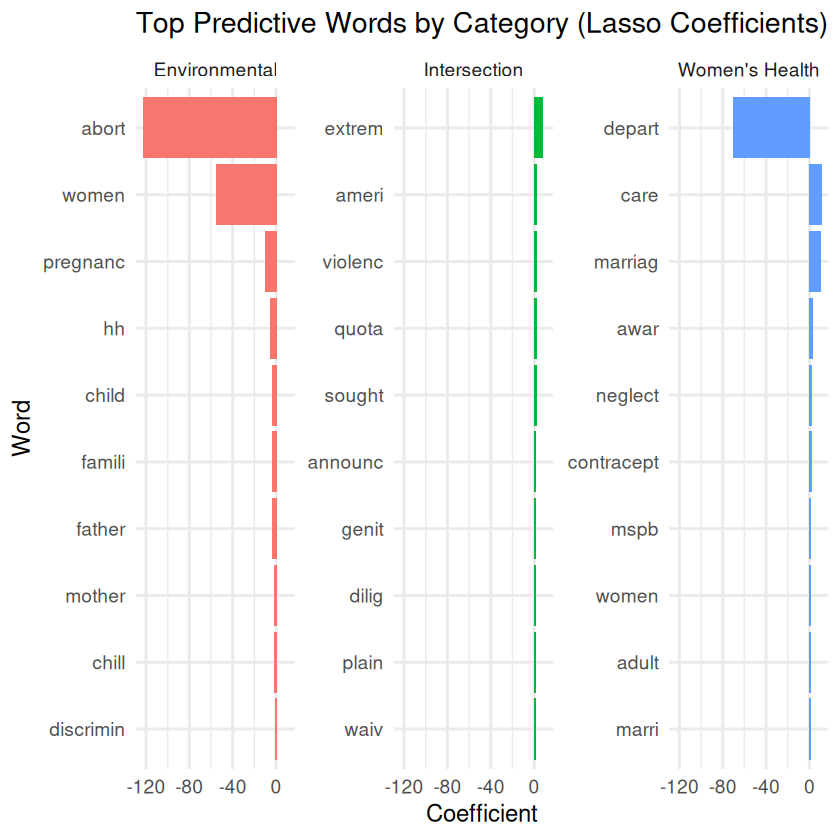

In [45]:
#plot top predictive words
top_words_by_category %>%
  mutate(term = reorder_within(term, abs(estimate), category)) %>%
  
ggplot(aes(x = term, y = estimate, fill = category)) +
  geom_col(show.legend = FALSE) +
  scale_x_reordered() +
  coord_flip() +
  facet_wrap(~ category, scales = "free_y") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Top Predictive Words by Category (Lasso Coefficients)",
    x = "Word",
    y = "Coefficient"
  )
  


**Summary/Conclusions** This project used NLP analyses of 'Mandate for Leadership Project 2025' to examine tensions between pronatalism and environmental regulation. Results show mostly neutral language with ideological spikes around the FACE Act, minimal overlap between environmental and women’s health terms and weak environmental signals, revealing a policy disconnect between environmental regulation and healthy pregnancy outcomes.